<a href="https://colab.research.google.com/github/lyssethpitti-debug/Modelo-Matlab/blob/main/Ecuaci%C3%B3n_de_calor_MNUMAV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

lambda = 0.456
Condición de estabilidad cumplida.

Tabla completa de temperaturas:
             x=0.0 m     x=0.2 m     x=0.5 m     x=0.8 m     x=1.0 m  \
t=0 s      20.312500   20.000000   20.000000   20.000000   20.000000   
t=250 s    32.955000   32.642500   32.500000   32.500000   32.500000   
t=500 s    45.532520   45.220020   45.064980   45.000000   45.000000   
t=750 s    58.104322   57.791822   57.606047   57.529631   57.500000   
t=1000 s   70.662109   70.349609   70.155915   70.050965   70.013512   
t=1250 s   83.216284   82.903784   82.696382   82.581743   81.983962   
t=1500 s   95.764209   95.451709   95.238682   94.861430   93.771055   
t=1750 s  108.309569  107.997069  107.663795  107.036246  105.064963   
t=2000 s  120.800096  120.487596  120.029606  118.923504  116.117613   
t=2250 s  133.233752  132.921252  132.234067  130.648400  126.767731   
t=2500 s  145.562896  145.250396  144.324359  142.101879  137.171970   
t=2750 s  157.783123  157.470623  156.233181  153.367

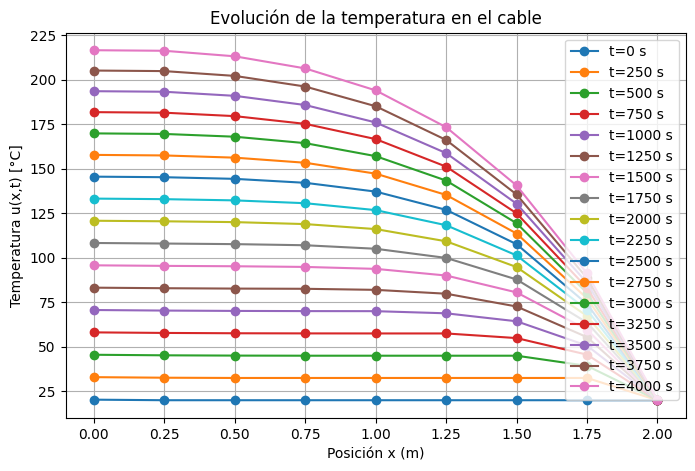

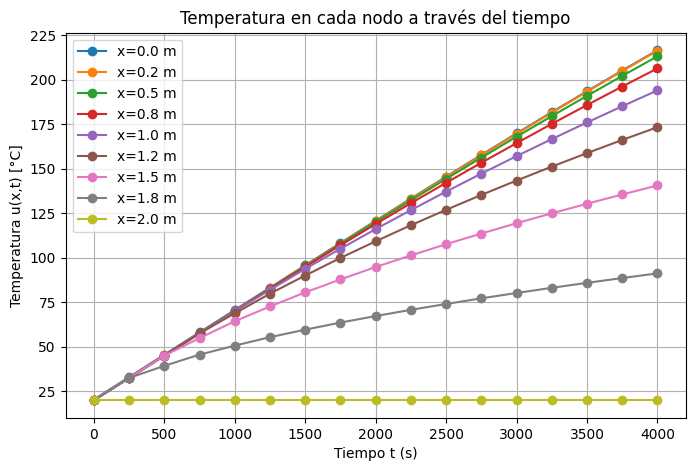

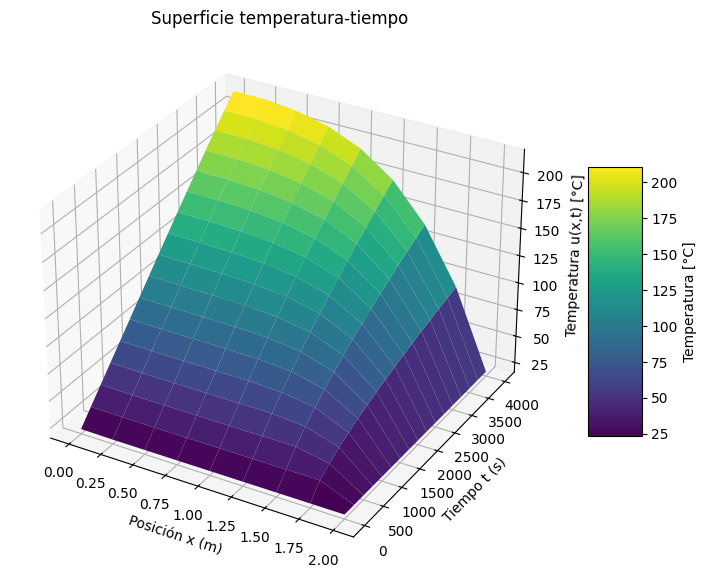

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# DATOS DEL PROBLEMA
# ============================================================

L = 2.0                 # Longitud del cable, m
T = 4000.0              # Tiempo final, s
gamma2 = 1.14e-4        # Difusividad térmica, m^2/s
k_cond = 400.0          # Conductividad térmica, W/(m K)
q = 500.0               # Flujo de calor, W/m^2
f = 0.05                # Fuente Joule, K/s

h = 0.25                 # Paso espacial
dt = 250.0             # Paso temporal

# ============================================================
# MALLA
# ============================================================

x = np.arange(0, L + h, h)
t = np.arange(0, T + dt, dt)

Nx = len(x) - 1
Nt = len(t) - 1

# Parámetro lambda
lam = gamma2 * dt / h**2

print("lambda =", lam)

if lam <= 0.5:
    print("Condición de estabilidad cumplida.")
else:
    print("Advertencia: no se cumple la condición de estabilidad.")

# ============================================================
# MATRIZ DE SOLUCIÓN
# U[n, i] representa u_i^n
# ============================================================

U = np.zeros((Nt + 1, Nx + 1))

# Condición inicial
U[0, :] = 20.0

# Condición de frontera derecha Dirichlet
U[:, -1] = 20.0

# Condición izquierda Neumann
# u_x(0,t) = -q/k
# (u_1^n - u_0^n)/h = -q/k
# u_0^n = u_1^n + (q/k)h

U[0, 0] = U[0, 1] + (q / k_cond) * h

# ============================================================
# ESQUEMA EXPLÍCITO
# ============================================================

for n in range(0, Nt):

    # Actualizar nodos interiores
    for i in range(1, Nx):
        U[n + 1, i] = (
            U[n, i]
            + lam * (U[n, i - 1] - 2 * U[n, i] + U[n, i + 1])
            + dt * f
        )

    # Frontera derecha Dirichlet
    U[n + 1, Nx] = 20.0

    # Frontera izquierda Neumann
    U[n + 1, 0] = U[n + 1, 1] + (q / k_cond) * h

# ============================================================
# TABLA DE RESULTADOS
# ============================================================

df = pd.DataFrame(
    U,
    index=[f"t={int(tt)} s" for tt in t],
    columns=[f"x={xx:.1f} m" for xx in x]
)

print("\nTabla completa de temperaturas:")
print(df)

# Guardar tabla en CSV
df.to_csv("tabla_temperaturas.csv")

# ============================================================
# GRÁFICO 2D: perfiles de temperatura
# ============================================================

plt.figure(figsize=(8, 5))

for n in range(Nt + 1):
    plt.plot(x, U[n, :], marker="o", label=f"t={int(t[n])} s")

plt.xlabel("Posición x (m)")
plt.ylabel("Temperatura u(x,t) [°C]")
plt.title("Evolución de la temperatura en el cable")
plt.grid(True)
plt.legend()
plt.savefig('temperatura_2d_perfiles.png', dpi=300)
plt.show()

# ============================================================
# GRÁFICO 2D: evolución temporal en cada nodo
# ============================================================

plt.figure(figsize=(8, 5))

for i in range(Nx + 1):
    plt.plot(t, U[:, i], marker="o", label=f"x={x[i]:.1f} m")

plt.xlabel("Tiempo t (s)")
plt.ylabel("Temperatura u(x,t) [°C]")
plt.title("Temperatura en cada nodo a través del tiempo")
plt.grid(True)
plt.legend()
plt.savefig('temperatura_2d_evolucion.png', dpi=300)
plt.show()

# ============================================================
# GRÁFICO 3D
# ============================================================

X, TT = np.meshgrid(x, t)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Añadimos cmap='viridis' y `rstride`, `cstride` para que el color se mapee a la temperatura
surf = ax.plot_surface(X, TT, U, cmap='viridis', rstride=1, cstride=1)

ax.set_xlabel("Posición x (m)")
ax.set_ylabel("Tiempo t (s)")
ax.set_zlabel("Temperatura u(x,t) [°C]")
ax.set_title("Superficie temperatura-tiempo")

# Añadimos una barra de color para indicar la escala de temperatura
fig.colorbar(surf, shrink=0.5, aspect=5, label='Temperatura [°C]')
fig.savefig('temperatura_3d_superficie.png', dpi=300)
plt.show()

### Animación 3D de la Evolución de la Temperatura

Para visualizar la evolución de la temperatura en el cable como un "video" en 3D, podemos crear una animación. Esta animación mostrará cómo cambia la superficie de temperatura a lo largo del tiempo.

In [5]:
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# Crear la figura y el eje 3D
fig_anim = plt.figure(figsize=(10, 7))
ax_anim = fig_anim.add_subplot(111, projection='3d')

# Configurar etiquetas del eje
ax_anim.set_xlabel('Posición x (m)')
ax_anim.set_ylabel('Tiempo t (s)')
ax_anim.set_zlabel('Temperatura u(x,t) [°C]')
ax_anim.set_title('Animación 3D de la Evolución de la Temperatura')

# Establecer límites fijos para el eje Z para una mejor visualización de la animación
ax_anim.set_zlim(np.min(U) * 0.9, np.max(U) * 1.1) # Ajustar límites basados en los datos

# Inicializar la superficie 3D con el primer paso de tiempo
surf = ax_anim.plot_surface(X[0:1,:], TT[0:1,:], U[0:1,:], cmap='viridis')

# Función de actualización para cada fotograma de la animación
def update(n):
    ax_anim.clear() # Limpiar el eje para redibujar

    ax_anim.set_xlabel('Posición x (m)')
    ax_anim.set_ylabel('Tiempo t (s)')
    ax_anim.set_zlabel('Temperatura u(x,t) [°C]')
    ax_anim.set_title(f'Animación 3D de la Evolución de la Temperatura (t={int(t[n])} s)')

    ax_anim.set_zlim(np.min(U) * 0.9, np.max(U) * 1.1)

    # Plotear la superficie hasta el tiempo actual 'n'
    surf = ax_anim.plot_surface(X[:n+1,:], TT[:n+1,:], U[:n+1,:], cmap='viridis')

    return surf,

# Crear la animación
# interval: Retraso entre fotogramas en ms (aumentado para un paso más lento)
# frames: Número total de fotogramas (igual a Nt + 1)
# blit: Si es True, solo se redibujan las partes cambiadas (puede optimizar, pero a veces causa problemas con 3D)
ani = animation.FuncAnimation(fig_anim, update, frames=Nt + 1, interval=1000, blit=False) # Intervalo cambiado a 1000ms

# Guardar la animación como un archivo GIF
# Requiere ffmpeg o ImageMagick. Si no está instalado, se puede usar `pip install imageio` y `ani.save('temperatura_3d_animacion.gif', writer='pillow')`
print("Guardando animación... esto puede tardar un momento.")
ani.save('temperatura_3d_animacion.gif', writer='pillow', fps=2) # FPS cambiado a 2 para un video más lento
print("Animación guardada como 'temperatura_3d_animacion.gif'")

plt.close(fig_anim) # Cerrar la figura para evitar que se muestre como un gráfico estático

Guardando animación... esto puede tardar un momento.
Animación guardada como 'temperatura_3d_animacion.gif'


El archivo `temperatura_3d_animacion.gif` se ha generado y guardado en su entorno de Colab. Puede descargarlo desde el panel de archivos.

### Explicación del Código de Colores del Gráfico 3D

El gráfico 3D utiliza la paleta de colores `viridis`. Esta es una **escala de colores perceptualmente uniforme**, lo que significa que los cambios de color corresponden de manera consistente a los cambios en los datos, sin introducir artefactos visuales o sesgos.

En la paleta `viridis`:

*   **Los colores más oscuros (azules y púrpuras)** representan los valores **más bajos** de temperatura.
*   **Los colores más claros (amarillos y verdes brillantes)** representan los valores **más altos** de temperatura.

Esta elección de `viridis` es común en la visualización científica porque es:

1.  **Perceptualmente uniforme**: Evita que ciertas regiones de datos parezcan más importantes de lo que realmente son.
2.  **Amigable para daltónicos**: Es legible para personas con diversas formas de daltonismo.
3.  **Robusta**: Funciona bien tanto en pantallas a color como en escalas de grises.

Por lo tanto, en tu gráfico 3D, puedes interpretar que las áreas más **azules/púrpuras** de la superficie indican temperaturas más bajas, mientras que las áreas más **amarillas/verdes** indican temperaturas más altas.

### Visualización de la Malla Espacial

Primero, visualicemos la malla espacial que define los puntos a lo largo del cable donde se calcula la temperatura. Esto nos da una idea de la discretización del dominio.

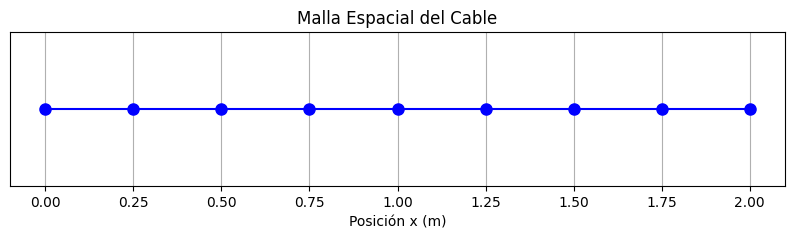

In [6]:
plt.figure(figsize=(10, 2))
plt.plot(x, np.zeros_like(x), 'o-', markersize=8, color='blue')
plt.xlabel('Posición x (m)')
plt.title('Malla Espacial del Cable')
plt.yticks([]) # Ocultar el eje Y ya que es una representacion 1D
plt.grid(True)
plt.savefig('malla_espacial.png', dpi=300)
plt.show()

### Gráfico de Calor (Heatmap) 2D de la Temperatura

Este gráfico en 2D nos permite ver la distribución de la temperatura a lo largo del cable (eje X) y cómo evoluciona en el tiempo (eje Y) de una manera compacta, utilizando colores para representar los valores de temperatura. Es una proyección 2D de la información de tu gráfico 3D.

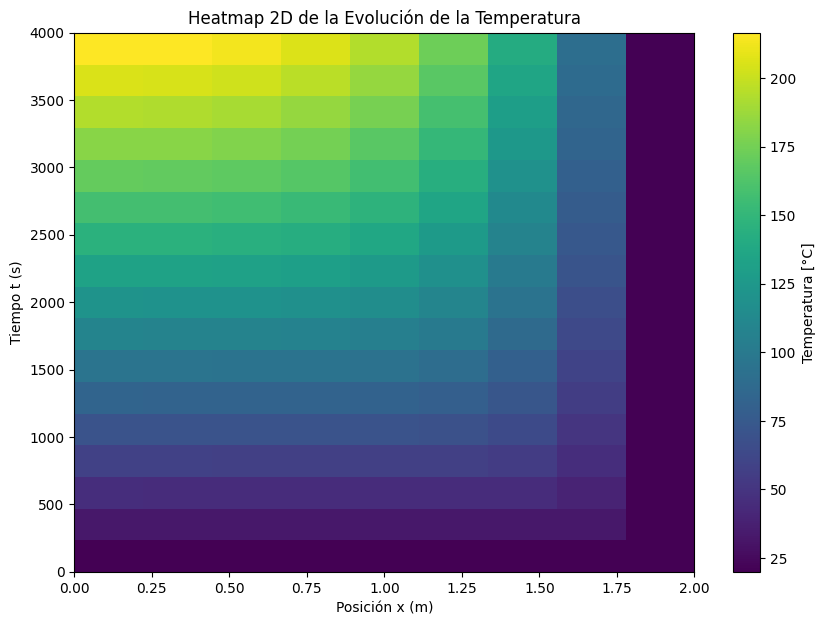

In [7]:
plt.figure(figsize=(10, 7))

# Usamos imshow para crear el heatmap. El origen se establece en 'lower' para que el tiempo aumente hacia arriba.
# extent define los límites de los ejes (xmin, xmax, ymin, ymax)
# aspect='auto' para que el gráfico se ajuste al tamaño de la figura
plt.imshow(U, origin='lower', extent=[x.min(), x.max(), t.min(), t.max()], aspect='auto', cmap='viridis')

plt.colorbar(label='Temperatura [°C]')
plt.xlabel('Posición x (m)')
plt.ylabel('Tiempo t (s)')
plt.title('Heatmap 2D de la Evolución de la Temperatura')
plt.savefig('heatmap_temperatura.png', dpi=300)
plt.show()